In [1]:
!pip install pyDOE

In [2]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np


from scipy.optimize import fsolve

In [3]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [4]:
t0, tfinal = 0.0, 5.0

In [5]:
k = 1.0
l = 2.0

In [29]:
#@jax.jit
def newton(A, G, A_0, F_0, G_0, E) :

  # print("------------------------------------------------------------------------------------------")

  # print("A", A)
  # print("G", G)

  F = ((4*E - (A**2/l**2) - ((2*(G**2))/(k**2 + l**2)))*(k**2))

  # print("F square", F)

  # print("------------------------------------------------------------------------------------------")

  F = jnp.sqrt(F)

  dF_dA = -(A*(k**2))/(F*(l**2))
  dF_dG = -(2*G*(k**2))/(F*(k**2 + l**2))

  D = (A - A_0)**2 + (F - F_0)**2 + (G - G_0)**2

  H1 = 2*(A - A_0) + 2*(F - F_0)*dF_dA
  H2 = 2*(F - F_0)*dF_dG + 2*(G - G_0)

  H = jnp.array([[H1], [H2]])

  dH1_dA = 2 - (2*(k**2))/(l**2) + ((2*(k**2)*F_0)/(l**2))*((F - (A*dF_dA))/(F**2))
  dH1_dG = -((2*(k**2)*F_0*A)/((F**2)*(l**2)))*dF_dG

  dH2_dA = -((4*(k**2)*F_0*G)/((F**2)*(k**2 + l**2)))*dF_dA
  dH2_dG = -((4*(k**2))/(k**2 + l**2)) + ((4*(k**2)*F_0)/(k**2 + l**2))*((F - (G*dF_dG))/(F**2)) + 2

  J = jnp.array([[dH1_dA, dH1_dG], [dH2_dA, dH2_dG]])

  J = jnp.squeeze(J)
  H = jnp.squeeze(H)

  J_inv = jnp.linalg.inv(J)

  # print("WE HERE")

  return J_inv, H


In [7]:
#@jax.jit
def distance_eq(vals) :

  A_0, F_0, G_0, E_0 = vals

  iter = 0
  err = 1000
  delta = 0.01

  A = A_0 + delta
  F = F_0 + delta
  G = G_0 + delta


  print("------------------------------------------------------------------------------------------")

  print("A", A)

  print("G", G)


  print("------------------------------------------------------------------------------------------")

  x_curr = jnp.array([[A], [G]])

  while (iter < 5) :

    J_inv, H = newton(A, G, A_0, F_0, G_0, E_0)

    mask_J_inv = jnp.isnan(J_inv)
    J_inv = jnp.where(mask_J_inv, 0, J_inv)

    mask_H = jnp.isnan(H)
    H = jnp.where(mask_H, 0, H)

    x_next = x_curr - jnp.matmul(J_inv, H)

    iter = iter + 1

    x_curr = x_next

    A = x_curr[0][0]
    G = x_curr[1][0]

  F = jnp.sqrt(((4*E_0 - (A**2/l**2) - ((2*(G**2))/(k**2 + l**2)))*(k**2)))

  return A, F, G

#@jax.jit
def find_closest(vals) :

  return jax.vmap(distance_eq, 0)(vals)

In [8]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [9]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [10]:
class ClosestPoint(nn.Module):

  E_0: float

  @nn.compact
  def __call__(self, inputs):

    A, F, G = inputs

    A_final, F_final, G_final = find_closest([A, F, G, self.E_0])

    return A_final, F_final, G_final

In [11]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [12]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [13]:
def define_collocation_points(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  As = np.random.uniform(0.0, 1.0, size = (N, 1))
  Fs = np.random.uniform(0.0, 1.0, size = (N, 1))
  Gs = np.random.uniform(0.0, 1.0, size = (N, 1))
  Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
  Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))

  sensor_points = np.column_stack((As, Fs, Gs, Es, Vs))

  return (ode_points, sensor_points)

In [14]:
(de_points, sensors) = define_collocation_points([t0, tfinal], 500)
print(de_points.shape, sensors.shape)

(500, 1) (500, 5)


In [15]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [16]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 1.0
  V_loss_w = 1.0

  E_0_val = z[:, -2]
  V_0_val = z[:, -1]

  A_val = var(t, z, 0, params)
  F_val = var(t, z, 1, params)
  G_val = var(t, z, 2, params)

  E_val = (1/4)*((A_val**2/l**2) + (F_val**2/k**2) + (2*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E_0_val
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)


  V_val = (1/2)*(A_val**2 + F_val**2 + 2*(G_val**2))
  V_loss = V_val - V_0_val
  V_loss = jnp.square(V_loss)
  V_loss = jnp.mean(V_loss)


  A_t_val = var_t(t, z, 0, params)
  F_t_val = var_t(t, z, 1, params)
  G_t_val = var_t(t, z, 2, params)

  A_t_loss = A_t_val + (1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)


  F_t_loss = F_t_val - (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

  return final_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [17]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [18]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [19]:
epochs = 1000
params, loss = train_network(params, de_points, sensors, epochs)

batch size: 50
Loss in epoch 0: 0.09596353530883789
Loss in epoch 100: 0.0020376412570476533
Loss in epoch 200: 0.0017840427160263062
Loss in epoch 300: 0.000980892851948738
Loss in epoch 400: 0.003476537764072418
Loss in epoch 500: 0.0009961699694395066
Loss in epoch 600: 0.0005899302661418915
Loss in epoch 700: 0.0006310446560382843
Loss in epoch 800: 0.0007693244516849518
Loss in epoch 900: 0.0004636836424469948


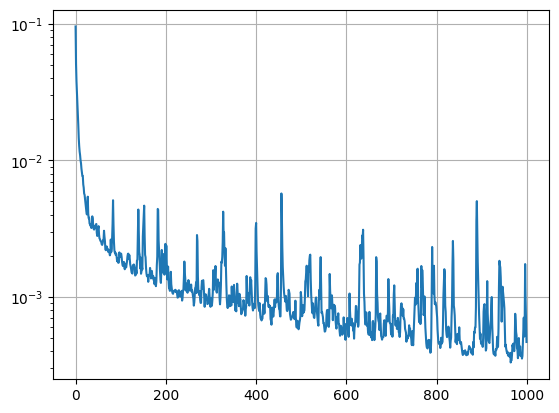

In [20]:
plt.semilogy(loss)
plt.grid()

In [21]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(0.0, 1.0, size=(1,))
F_data = np.random.uniform(0.0, 1.0, size=(1,))
G_data = np.random.uniform(0.0, 1.0, size=(1,))
E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data_rk = np.column_stack((A_data, F_data, F_data))
init_data_rk = np.squeeze(init_data_rk)

init_data_model = np.column_stack((A_data, F_data, G_data, E_data, V_data))
init_data_model = np.squeeze(init_data_model)
print(init_data_model.shape)

z = np.repeat(np.expand_dims(init_data_model, axis=0), len(t), axis=0)
print(z.shape)

(5,)
(500, 5)


In [22]:
sol_rk = odeint(Lorenz1960, init_data_rk, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]

In [23]:
A = jax.vmap(var_model, [0, 0, None, None])(t, z, 0, params)
F = jax.vmap(var_model, [0, 0, None, None])(t, z, 1, params)
G = jax.vmap(var_model, [0, 0, None, None])(t, z, 2, params)

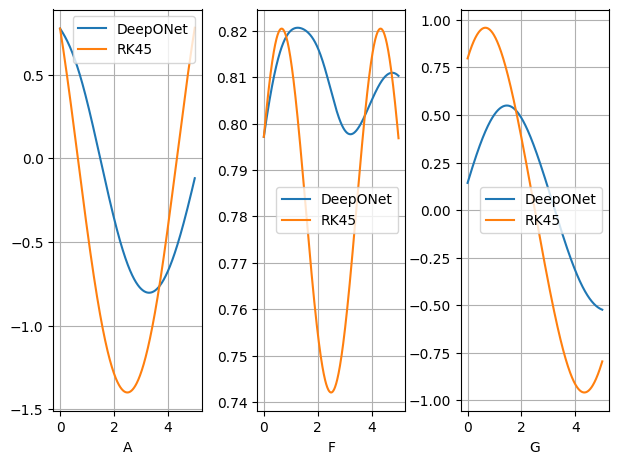

In [24]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()

In [25]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])


    A, F, G = ClosestPoint(E_0)([A, F, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [26]:
#@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

#@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

#@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

#@jax.jit
def Closs(params, t, z):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 0.0
  V_loss_w = 0.0

  E_0_val = z[:, -2]
  V_0_val = z[:, -1]

  A_val = Cvar(t, z, 0, params)
  F_val = Cvar(t, z, 1, params)
  G_val = Cvar(t, z, 2, params)

  E_val = (1/4)*((A_val**2/l**2) + (F_val**2/k**2) + (2*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E_0_val
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)


  V_val = (1/2)*(A_val**2 + F_val**2 + 2*(G_val**2))
  V_loss = V_val - V_0_val
  V_loss = jnp.square(V_loss)
  V_loss = jnp.mean(V_loss)


  A_t_val = Cvar_t(t, z, 0, params)
  F_t_val = Cvar_t(t, z, 1, params)
  G_t_val = Cvar_t(t, z, 2, params)

  A_t_loss = A_t_val + (1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)


  F_t_loss = F_t_val - (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

  return final_loss

#@jax.jit
def Ctrain_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(Closs)(params, t, z)

#@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [27]:
def Ctrain_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [30]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

------------------------------------------------------------------------------------------
A Traced<ShapedArray(float32[1])>with<BatchTrace(level=1/0)> with
  val = Array([[0.95091337],
       [0.95091337],
       [0.95091337],
       [0.95091337],
       [0.95091337],
       [0.95091337],
       [0.95091337],
       [0.95091337],
       [0.95091337],
       [0.95091337]], dtype=float32)
  batch_dim = 0
G Traced<ShapedArray(float32[1])>with<BatchTrace(level=1/0)> with
  val = Array([[1.3798351],
       [1.3798351],
       [1.3798351],
       [1.3798351],
       [1.3798351],
       [1.3798351],
       [1.3798351],
       [1.3798351],
       [1.3798351],
       [1.3798351]], dtype=float32)
  batch_dim = 0
------------------------------------------------------------------------------------------


In [31]:
Cparams = copy.deepcopy(params)

In [32]:
epochs = 100
Cparams, Closs = Ctrain_network(Cparams, de_points, sensors, epochs)

Streaming output truncated to the last 5000 lines.

       [[nan]]], dtype=float32)
      tangent = Traced<ShapedArray(float32[50,1,1])>with<JaxprTrace(level=1/0)> with
        pval = (ShapedArray(float32[50,1,1]), None)
        recipe = JaxprEqnRecipe(eqn_id=<object object at 0x78c59d5043c0>, in_tracers=(Traced<ShapedArray(float32[50,1,1]):JaxprTrace(level=1/0)>,), out_tracer_refs=[<weakref at 0x78c5a85a2160; to 'JaxprTracer' at 0x78c5a85a1940>], out_avals=[ShapedArray(float32[50,1,1])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[50,1,1]. let  in (a,) }, 'in_shardings': (UnspecifiedValue,), 'out_shardings': (UnspecifiedValue,), 'resource_env': None, 'donated_invars': (False,), 'name': 'fn', 'keep_unused': False, 'inline': True}, effects=set(), source_info=SourceInfo(traceback=<jaxlib.xla_extension.Traceback object at 0x5b0c1073c5a0>, name_stack=NameStack(stack=(Transform(name='jvp'), Transform(name='vmap'), Scope(name='CDeepONet'), Scope(name='ClosestPoint_0'), Transform(name='

KeyboardInterrupt: 

In [ ]:
plt.semilogy(Closs)
plt.grid()

In [ ]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 2, Cparams)

In [ ]:
print(A)

In [ ]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()
